# AAV1 / sucrose hydrogen-bond analysis

Companion to `pic_analysis.ipynb` — same conditions and plotting style, but the
observable is **sucrose–protein hydrogen bonds** instead of Γ₂₃.

H-bonds come from the geometric detections in `hbonds-exterior/` (D–A ≤ 3.5 Å,
D–H–A ≥ 150°) re-joined to the **better-selection** 3F/5F regions in this folder.
Detections are region-independent, so nothing here touches the trajectories: it
reads the annotated parquets + the tight-core region assignments.


## 0 · Setup & data loading

In [1]:
import re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 12, "font.family": "Calibri",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#1b2624", "text.color": "#1b2624",
    "axes.labelcolor": "#1b2624", "xtick.color": "#1b2624", "ytick.color": "#1b2624",
})
TEAL, PLUM, AMBER, GREY = "#1f6f5c", "#7a3b66", "#a15c00", "#8a948e"
INK, GRID = "#1b2624", "#d8dcda"
CORR = 8.5   # frame-correlation SEM inflation (see pic_analysis Section 0)

ROOT        = Path(".")                      # this notebook's folder (better-selection regions live here)
REGION_ROOT = ROOT                           # <cond>/pic_symmetry_regions/per_residue.csv
HB_ROOT     = Path("../../hbonds-exterior")  # <cond>/hbonds_annotated.parquet

FORMULATIONS = {(6.0,110,8):("C",1), (7.3,170,5):("F",2), (6.0,30,12):("D",3), (7.3,30,12):("E",4)}
STABILITY_ORDER = ["C", "F", "D", "E"]       # best -> worst (wet-lab ranking)
FOLDER_RE = re.compile(r"^10ns_aav1ph(\d+)salt(\d+)suc(\d+)$")
def decode_ph(raw): return float(raw) if len(raw) == 1 else float(raw[0] + "." + raw[1:])

def load_condition(name):
    """Whole-capsid H-bonds/frame + per-region-INSTANCE H-bond counts and residue
    counts (20 three-fold, 12 five-fold), all exterior-facing, better-selection regions."""
    m = FOLDER_RE.match(name)
    if not m:
        return None
    ph, salt, suc = decode_ph(m.group(1)), int(m.group(2)), int(m.group(3))
    reg_csv = REGION_ROOT / name / "pic_symmetry_regions" / "per_residue.csv"
    pq      = HB_ROOT / name / "hbonds_annotated.parquet"
    if not (reg_csv.is_file() and pq.is_file()):
        return None
    reg = pd.read_csv(reg_csv)
    reg = reg[reg["facing_outer"] == True].copy()          # sucrose only reaches the exterior
    reg["key"] = list(zip(reg["chain"].astype(int), reg["resid"].astype(int)))
    rt_map = dict(zip(reg["key"], reg["region_type"].fillna("")))
    ri_map = dict(zip(reg["key"], reg["region_index"]))

    hb = pd.read_parquet(pq, columns=["frame", "prot_chain", "prot_resid"])
    nfr = hb["frame"].nunique()
    per_frame = hb.groupby("frame").size()
    whole, whole_sem = per_frame.mean(), per_frame.std(ddof=1) / np.sqrt(nfr)
    hb["key"] = list(zip(hb["prot_chain"].astype(int), hb["prot_resid"].astype(int)))
    hb["rt"]  = hb["key"].map(rt_map)
    hb["ri"]  = hb["key"].map(ri_map)

    reg_arr = {}
    for rt in ("3F", "5F"):
        nper = reg[reg["region_type"] == rt].groupby("region_index").size()
        idx  = sorted(nper.index)
        cper = hb[hb["rt"] == rt].groupby("ri").size() / nfr
        reg_arr[rt] = (np.array([cper.get(i, 0.0) for i in idx]),
                       np.array([float(nper.get(i, 0)) for i in idx]))

    tag = FORMULATIONS.get((ph, salt, suc))
    return dict(name=name, ph=ph, salt=salt, suc=suc, nframes=nfr,
                whole=whole, whole_sem=whole_sem,
                reg3_count=reg_arr["3F"][0], reg3_n=reg_arr["3F"][1],
                reg5_count=reg_arr["5F"][0], reg5_n=reg_arr["5F"][1],
                label=tag[0] if tag else None, rank=tag[1] if tag else None)

names = sorted(p.name for p in HB_ROOT.iterdir() if p.is_dir()) if HB_ROOT.is_dir() else []
CONDITIONS = [c for c in (load_condition(n) for n in names) if c]
BY_KEY = {(c["ph"], c["salt"], c["suc"]): c for c in CONDITIONS}

print(f"loaded {len(CONDITIONS)} conditions from {HB_ROOT}")
for c in sorted(CONDITIONS, key=lambda c: (c["ph"], c["salt"], c["suc"])):
    tag = f"  [{c['label']}]" if c["label"] else ""
    print(f"  pH{c['ph']:<4g} {c['salt']:>4d} mM  {c['suc']:>2d}% suc   "
          f"{c['whole']:7.1f} H-bonds/frame{tag}")

loaded 12 conditions from ..\..\hbonds-exterior
  pH6      30 mM   1% suc      24.5 H-bonds/frame
  pH6      30 mM  10% suc     176.9 H-bonds/frame
  pH6      30 mM  12% suc     210.7 H-bonds/frame  [D]
  pH6     110 mM   8% suc     162.9 H-bonds/frame  [C]
  pH6     200 mM   1% suc      20.6 H-bonds/frame
  pH6     200 mM  10% suc     196.0 H-bonds/frame
  pH7.3    30 mM  12% suc     187.8 H-bonds/frame  [E]
  pH7.3   170 mM   5% suc      92.0 H-bonds/frame  [F]
  pH8      30 mM   1% suc      19.3 H-bonds/frame
  pH8      30 mM  10% suc     155.5 H-bonds/frame
  pH8     200 mM   1% suc      15.7 H-bonds/frame
  pH8     200 mM  10% suc     156.5 H-bonds/frame


## 1 · All 12 conditions by H-bonds\n\nSection-5 style. Left = whole-capsid sucrose–protein H-bonds/frame (exterior). Right = per-region-instance density (each dot = one of the 20 three-fold / 12 five-fold axes; bold dot = region mean).\n\n**Options:** `USE_TOTAL` toggles the right panel between H-bonds **per residue** and **total** H-bonds/frame per region; `SORT_BY` orders rows by `"whole"` (default), `"3F"`, `"5F"`, or `"avg"`.

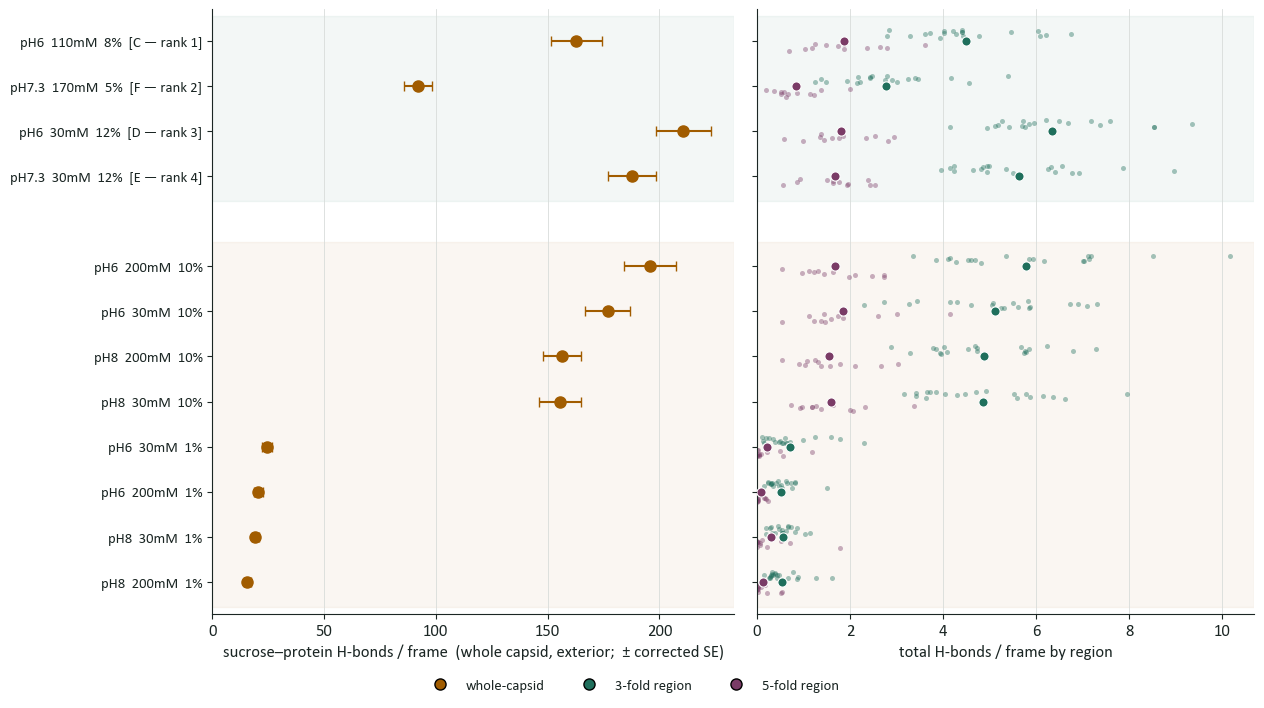

In [3]:
# ---- OPTIONS (edit, then re-run) -------------------------------------------
USE_TOTAL = True   # right panel: False = H-bonds per residue; True = total H-bonds/frame per region instance
SORT_BY   = "whole" # row order: "whole" (whole-capsid H-bonds; formulations keep stability rank) | "3F" | "5F" | "avg"
# ---------------------------------------------------------------------------

def region_vals(c, region):
    """Per-instance values in the right panel: H-bonds per residue, or (USE_TOTAL) total H-bonds/frame."""
    count = c["reg3_count"] if region == "3F" else c["reg5_count"]
    n     = c["reg3_n"]     if region == "3F" else c["reg5_n"]
    if count.size == 0:
        return count
    if USE_TOTAL:
        return count
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(n > 0, count / n, np.nan)

def region_scalar(c, region):
    v = region_vals(c, region); v = v[np.isfinite(v)]
    return v.mean() if v.size else np.nan

def sort_metric(c):
    if SORT_BY == "3F":  return region_scalar(c, "3F")
    if SORT_BY == "5F":  return region_scalar(c, "5F")
    if SORT_BY == "avg": return np.nanmean([region_scalar(c, "3F"), region_scalar(c, "5F")])
    return c["whole"]                                    # "whole"

def _sort_key(c):
    m = sort_metric(c)
    return -m if np.isfinite(m) else 1e18

forms = [c for c in CONDITIONS if c["label"]]
does  = [c for c in CONDITIONS if not c["label"]]
forms = sorted(forms, key=lambda c: c["rank"]) if SORT_BY == "whole" else sorted(forms, key=_sort_key)
does  = sorted(does, key=_sort_key)
ordered = forms + [None] + does

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.8, 7.0), gridspec_kw={"width_ratios": [1.05, 1]})
rng = np.random.default_rng(7)
y, yticks, ylabels, pos = 0, [], [], {}
for c in ordered:
    if c is None:
        y -= 1; continue
    pos[id(c)] = y; yticks.append(y)
    tag = f"  [{c['label']} — rank {c['rank']}]" if c["label"] else ""
    ylabels.append(f"pH{c['ph']:g}  {c['salt']}mM  {c['suc']}%{tag}")
    y -= 1

f_ys = [pos[id(c)] for c in forms]; d_ys = [pos[id(c)] for c in does]
for ax in (axL, axR):
    ax.axhspan(max(f_ys)+0.55, min(f_ys)-0.55, color=TEAL, alpha=0.05, zorder=0)
    ax.axhspan(max(d_ys)+0.55, min(d_ys)-0.55, color=AMBER, alpha=0.05, zorder=0)

for c in forms + does:
    yy = pos[id(c)]
    axL.errorbar(c["whole"], yy, xerr=c["whole_sem"]*CORR, fmt="o", color=AMBER,
                 ecolor=AMBER, markersize=8, capsize=3.5, elinewidth=1.5, zorder=3)
    for region, color, sign in (("3F", TEAL, +1), ("5F", PLUM, -1)):
        vals = region_vals(c, region); vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        j = rng.uniform(0.06, 0.24, size=len(vals))
        axR.scatter(vals, yy + sign*j, s=13, color=color, alpha=0.4, linewidths=0, zorder=2)
        axR.scatter([vals.mean()], [yy], s=44, color=color, edgecolors="white", linewidths=0.8, zorder=4)

axL.set_xlabel("sucrose–protein H-bonds / frame  (whole capsid, exterior;  ± corrected SE)")
axR.set_xlabel(("total H-bonds / frame" if USE_TOTAL else "H-bonds per residue") + " by region")
for ax, tl in ((axL, ylabels), (axR, [])):
    ax.grid(True, axis="x", color=GRID, linewidth=0.6, zorder=0); ax.set_axisbelow(True)
    ax.set_yticks(yticks); ax.set_yticklabels(tl, fontsize=10.5)
    ax.set_ylim(min(yticks)-0.7, max(yticks)+0.7)
    ax.set_xlim(left=0)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
if SORT_BY != "whole":
    fig.suptitle(f"rows sorted by {SORT_BY} region H-bonds ({'total' if USE_TOTAL else 'per-residue'})",
                 y=0.995, fontsize=10.5, color="0.4")
fig.legend(handles=[
    Line2D([0],[0],marker='o',color='none',markerfacecolor=AMBER,markersize=8,label='whole-capsid'),
    Line2D([0],[0],marker='o',color='none',markerfacecolor=TEAL,markersize=8,label='3-fold region'),
    Line2D([0],[0],marker='o',color='none',markerfacecolor=PLUM,markersize=8,label='5-fold region'),
], loc="lower center", ncol=3, frameon=False, fontsize=10.5, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.02, 1, 1])